In [3]:
import numpy as np
import pandas as pd
import matplotlib as plt
import math

In [42]:
class Value:

    def __init__(self, data, child=(), op="", label=""):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._child = set(child)
        self._op = op
        self._backward = lambda: None
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, child=(self, other), op="+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, child=(self, other), op="*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        out = Value(self.data ** other, (self, ), "**{other}")
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def get_topo(self) -> list["Value"]:
        topo = []
        visited = set()
        def build_topo(v: "Value"):

            if v not in visited:
                visited.add(v)
                for child in v._child:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        return topo

    def backward(self):
        self.grad = 1
        nodes = self.get_topo()
        for node in nodes[::-1]:
            node._backward()


In [33]:
from graphviz import Digraph

def trace(root: Value):
    nodes, edges = set(), set()
    def _dfs(node):
        if node not in nodes:
            nodes.add(node)
            for child in node._child:
                _dfs(child)
                edges.add((child, node))
    _dfs(root)
    return nodes, edges

def draw_dot(root: Value):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"}) # LR: left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad)
        dot.node(name=uid, label=label, shape="record")
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [34]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a + b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label="L"

In [35]:
L.backward()

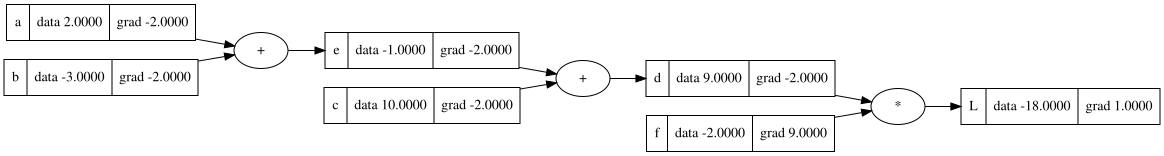

In [36]:
draw_dot(L)

In [39]:
# verify gradient

def lol():
    h = 0.001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a + b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label="L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a + b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0 + h, label="f")
    L = d * f; L.label="L"
    L2 = L.data

    return (L2 - L1) /h
lol()

9.000000000000341

In [43]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

b = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"
o.backward()

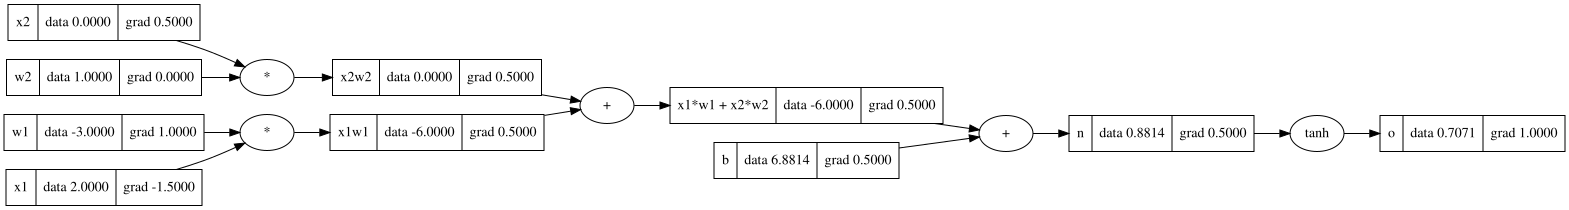

In [44]:
draw_dot(o)

In [45]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("-------------")
print("x1", x1.grad.item())
print("x2", x2.grad.item())
print("w1", w1.grad.item())
print("w2", w2.grad.item())

0.7071066904050358
-------------
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0
